### 1개 노드 연결하기 

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

# 1. 데이터 저장소
class MyState(TypedDict):
    message: str

# 2. 작업 함수 만들기
def say_hello(state):
    return {"message": "Hello, World!"}

# 3. 그래프 만들기
graph = StateGraph(MyState) # 만든 저장소를 사용하는 그래프
graph.add_node("hello", say_hello) # hello 노드 추가, say_hello 작업과 연결

graph.add_edge(START, "hello") # 시작 - hello 노드
graph.add_edge("hello", END) # hello 노드 - 종료

# 4. 그래프 실행하기
app = graph.compile() # 그래프를 실행 가능한 프로그램으로 변환
result = app.invoke({"message": ""}) # 빈 메시지로 프로그램을 시작
print(result)

{'message': 'Hello, World!'}


- mermaid

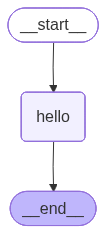

In [8]:
from IPython.display import display, Image

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"그래프 시각화 오류: {str(e)}")

## 2개 노드 연결하기

In [10]:
def first_increment(state):
    return {"message": state["message"] + 1}

def second_increment(state):
    return {"message": state["message"] + 2}

In [11]:
graph = StateGraph(MyState)
graph.add_node("first", first_increment)
graph.add_node("second", second_increment)

graph.add_edge(START, "first")
graph.add_edge("first", "second")
graph.add_edge("second", END)

app = graph.compile()
result = app.invoke({"message": 0})
print(result)

{'message': 3}


# 상태의 역할

- 일관서 유지를 위해 필요

In [ ]:
from typing import TypedDict

class ChatState(TypedDict):
    user_message: str # 현재 사용자 메세지
    chat_history: list # 이전 대화 기록
    user_context: dict # 사용자에 대한 추가 정보 (예: 이름, 선호도 등)
    system_status: str # 시스템의 현재 상태 (예: "대기 중", "처리 중", "완료" 등)

## Reducer - 상태 업데이트

- Guide

In [14]:
# before
old_state = {"counter": 5}
new_state = {"counter": 10}
result = {"counter": 10}

In [15]:
from operator import add

old_state = {"items": [1, 2, 3]}
new_state = {"items": [4, 5, 6]}
result = {"items": [1, 2, 3, 4, 5, 6]}

### from operator import add

In [ ]:
from typing import Annotated
from operator import add

class State(TypedDict):
    message_count: int # 기본
    conversation_history: Annotated[list, add]
    # list
    # Annotated[list, add]

def node_1(state: State) -> State:
    return {
        "message_count": 1,
        "conversation_history": ["안녕하세요."]
    }


def node_2(state: State) -> State:
    return {
        "message_count": state["message_count"] + 1,
        "conversation_history": ["어떻게 도와드릴까요?"]
    }


graph = StateGraph(State)
graph.add_node("node_1", node_1)
graph.add_node("node_2", node_2)

graph.add_edge(START, "node_1")
graph.add_edge("node_1", "node_2")
graph.add_edge("node_2", END)

app = graph.compile()
result = app.invoke({"message_count": 0, "conversation_history": []})

In [25]:
# list 형태로 메시지 출력
print(result)

{'message_count': 2, 'conversation_history': ['어떻게 도와드릴까요?']}


In [27]:
# Annotated[list, add]
print(result)

{'message_count': 2, 'conversation_history': ['안녕하세요.', '어떻게 도와드릴까요?']}


# 조건부 부분

## add_conditional_edges

### 2분할 (예제 1. 10보다 큰지? 작은지?)

In [ ]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class NumberState(TypedDict):
    number: int
    result: str

def handle_big_number(state):
    return {"result": f"{state['number']}는 큰 숫자 입니다."}

def handle_small_number(state):
    return {"result": f"{state['number']}는 작은 숫자입니다!"}

def check_size(state):
    if state['number'] > 10:
        return "big"
    else:
        return "small"
    
graph = StateGraph(NumberState)
graph.add_node("big_handler", handle_big_number)
graph.add_node("small_handler", handle_small_number)

graph.add_conditional_edges(
    START, 
    check_size, 
    {
        "big": "big_handler", # 'big'이면 bin_handler로 이동
        "small": "small_handler" # 'small'이면 small_handler로 이동
    }   
)


graph.add_edge("big_handler", END)
graph.add_edge("small_handler", END)

app = graph.compile()

result1 = app.invoke({"number": 15, "result": ""})
print(result1)

{'number': 15, 'result': '15는 큰 숫자 입니다.'}


In [33]:
result2 = app.invoke({"number": 5, "result": ""})
print(result2)

{'number': 5, 'result': '5는 작은 숫자입니다!'}


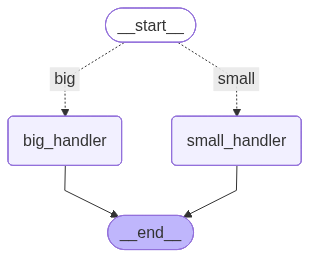

In [34]:
from IPython.display import display, Image

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"그래프 시각화 오류: {str(e)}")

### 3분할 (예제 2. 신호등 시스템)

In [38]:
class TrafficState(TypedDict):
    color: str
    action: str

def red_light(state):
    return {"action": "정지하세요! 🛑"}

def yellow_light(state):
    return {"action": "주의하세요! ⚠️"}

def green_light(state):
    return {"action": "출발하세요! 🟢"}

def check_color(state):
    color = state["color"] # .lower()
    if color == "red":
        return "red"
    elif color == "yellow":
        return "yellow"
    elif color == "green":
        return "green"
    
# 그래프 구성
graph = StateGraph(TrafficState)
graph.add_node("red_handler", red_light)
graph.add_node("yellow_handler", yellow_light)
graph.add_node("green_handler", green_light)

graph.add_conditional_edges(
    START,
    check_color,
    {
        "red": "red_handler",
        "yellow": "yellow_handler",
        "green": "green_handler"
    }
)


graph.add_edge("red_handler", END)
graph.add_edge("yellow_handler", END)  
graph.add_edge("green_handler", END)

app = graph.compile()
colors = ["red", "yellow", "green", "red"]

for c in colors:
    result = app.invoke({"color": c, "action": ""})
    print(result['color'])
    print(result['action'])
    print("-" * 30)


red
정지하세요! 🛑
------------------------------
yellow
주의하세요! ⚠️
------------------------------
green
출발하세요! 🟢
------------------------------
red
정지하세요! 🛑
------------------------------


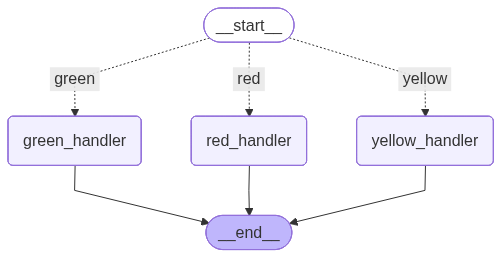

In [39]:
from IPython.display import display, Image

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"그래프 시각화 오류: {str(e)}")

# Send API
- from langgraph.types import Send

In [42]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send


class State(TypedDict):
    items: list[str]


def route_items(state: State):
    return [
        Send("worker", {"item": item})
        for item in state["items"]
    ]


def worker(state):
    print(state["item"])
    return {}


graph = StateGraph(State)

graph.add_node("worker", worker)

graph.add_conditional_edges(
    START,
    route_items,
    ["worker"]
)

graph.add_edge("worker", END)

app = graph.compile()

result = app.invoke({
    "items": ["사과", "바나나", "포도"]
})

print(result)

사과
바나나
포도
{'items': ['사과', '바나나', '포도']}


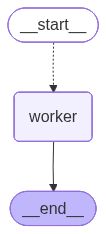

In [43]:
from IPython.display import display, Image

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"그래프 시각화 오류: {str(e)}")

START
  ↓
router
  ↓
Send("worker", {"item": "사과"})
Send("worker", {"item": "바나나"})
Send("worker", {"item": "포도"})
  ↓
worker 3번 실행
  ↓
END

# 그래프 실행 방법
- invoke: 배치 처리
- stream: 챗봇
- async: 비동기

# Memory
- 메모리 기본 설정

In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySerer # 1. 체크 포인터

# ...그래프...

memory = InMemorySerer() # 2. 체크 포인터 설정

app = graph.compile(checkpointer=memory) # 3. 그래프에 연결

## 예제 1. +10 기억하는 예제 만들기

In [49]:
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver
from typing import TypedDict

class CalculatorState(TypedDict):
    total: int        # 현재까지의 총합
    history: list     # 계산 기록

def add_number(state: CalculatorState) -> dict:
    current_total = state['total']
    number_to_add = 10

    new_total = current_total + number_to_add
    new_history = state['history'] + [f"{current_total} + {number_to_add} = {new_total}"]

    return {
        "total": new_total,
        "history": new_history
    }

graph = StateGraph(CalculatorState)
graph.add_node("add", add_number)

graph.add_edge(START, "add")
graph.add_edge("add", END)

memory = InMemorySaver()
app = graph.compile(checkpointer=memory)

# thread_id를 통해 어떤 대화(세션)의 상태를 불러올지 결정함
config = {
    "configurable": {
        "thread_id": "calculator_session"
    }
}


# 첫 번째 계산 - 초기 상태 제공
print("=== 첫 번째 계산 ===")
result = app.invoke({"total": 0, "history": []}, config=config)
print(f"결과: total={result['total']}, history={result['history']}\n")

# 두 번째 계산 - 이전 상태 자동 복원!
print("=== 두 번째 계산 ===")
result = app.invoke({}, config=config)
print(f"결과: total={result['total']}, history={result['history']}\n")

# 세 번째 계산
print("=== 세 번째 계산 ===")
result = app.invoke({}, config=config)  
print(f"결과: total={result['total']}, history={result['history']}")

=== 첫 번째 계산 ===
결과: total=10, history=['0 + 10 = 10']

=== 두 번째 계산 ===
결과: total=20, history=['0 + 10 = 10', '10 + 10 = 20']

=== 세 번째 계산 ===
결과: total=30, history=['0 + 10 = 10', '10 + 10 = 20', '20 + 10 = 30']


## 예제 2. 챗봇 구현

In [51]:
from typing import TypedDict
from langchain.chat_models import init_chat_model
from langchain.messages import AIMessage
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.checkpoint.memory import InMemorySaver

# 1단계: 모델 초기화
model = init_chat_model("openai:gpt-4.1-mini")

# 2단계: 챗봇 노드 정의
def chatbot_node(state: MessagesState) -> dict:
    # 모델을 호출하여 응답 생성
    response = model.invoke(state["messages"])

    # 응답을 messages 키에 담아 반환
    return {"messages": [response]}

checkpointer = InMemorySaver()

builder = StateGraph(MessagesState)

builder.add_node("chatbot", chatbot_node)

builder.add_edge(START, "chatbot")
builder.add_edge("chatbot", END)

graph = builder.compile(checkpointer=checkpointer)

config = {"configurable": {"thread_id": "conversation_1"}}

result1 = graph.invoke(
    {"messages": [{"role": "user", "content": "안녕하세요! 제 이름은 철수입니다."}]},
    config
)
print("AI 응답 1:", result1["messages"][-1].content)


result2 = graph.invoke(
    {"messages": [{"role": "user", "content": "제 이름이 뭐였죠?"}]},
    config
)
print("AI 응답 2:", result2["messages"][-1].content)


AI 응답 1: 안녕하세요, 철수님! 만나서 반갑습니다. 어떻게 도와드릴까요?
AI 응답 2: 철수님이라고 하셨습니다! 어떻게 기억해드릴까요?


In [58]:
from pprint import pprint

state = graph.get_state(config)

print("=== 저장된 상태 값 ===")
result = state.values
pprint(state.values)


=== 저장된 상태 값 ===
{'messages': [HumanMessage(content='안녕하세요! 제 이름은 철수입니다.', additional_kwargs={}, response_metadata={}, id='e4ec2d48-d596-4426-8289-02217a798589'),
              AIMessage(content='안녕하세요, 철수님! 만나서 반갑습니다. 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 17, 'total_tokens': 37, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp_2b1324456b', 'id': 'chatcmpl-DmfaOE7WVzsKYNMuEVPsnosmDvNKr', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e8d97-676a-7500-b3a7-2e04245cf313-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 17, 'output_tokens': 20, 'total_tokens': 37, 'input_token_details': {'aud

In [55]:
print("\n=== 설정 정보 ===")
pprint(state.config)


=== 설정 정보 ===
{'configurable': {'checkpoint_id': '1f15f4cf-fee7-6958-8004-c4b251a4cb4e',
                  'checkpoint_ns': '',
                  'thread_id': 'conversation_1'}}
